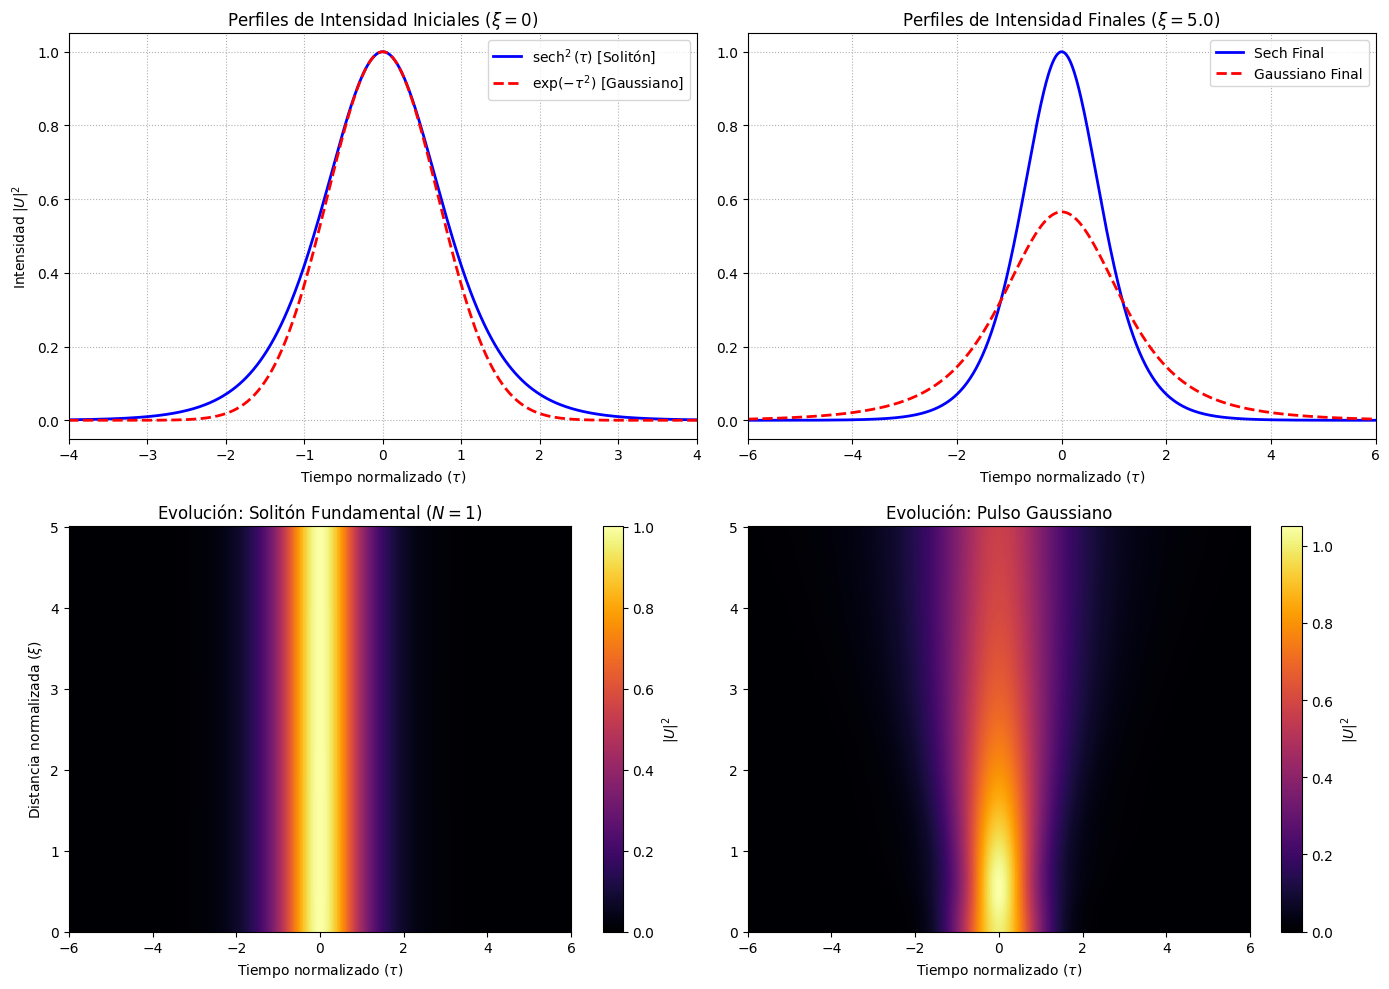

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# ==========================================
# 1. Parámetros de la Malla Computacional
# ==========================================
N_t = 2048          # Resolución temporal (potencia de 2 para FFT)
T_max = 15.0        # Ventana de tiempo normalizado
tau = np.linspace(-T_max, T_max, N_t)
dtau = tau[1] - tau[0]
omega = fftfreq(N_t, d=dtau) * 2 * np.pi

xi_max = 5.0        # Distancia de propagación normalizada
N_xi = 1000         # Pasos espaciales
dxi = xi_max / N_xi

# ==========================================
# 2. Inicialización de los Pulsos (z = 0)
# ==========================================
# Ambos inician con la misma potencia pico (N=1)
U_sech_0 = 1.0 / np.cosh(tau)              # Perfil Solitón (Secante Hiperbólica)
U_gauss_0 = np.exp(-(tau**2) / 2.0)        # Perfil Gaussiano estándar

# Copias para iterar en el bucle
U_sech = np.copy(U_sech_0)
U_gauss = np.copy(U_gauss_0)

# Matrices para almacenar la evolución completa (Mapas de calor)
evo_sech = np.zeros((N_xi, N_t))
evo_gauss = np.zeros((N_xi, N_t))

# ==========================================
# 3. Operador Lineal de Dispersión (GVD)
# ==========================================
# Asumimos GVD anómala (beta_2 < 0), lo que da un signo positivo
# en la NLSE adimensional para la segunda derivada.
# Al pasar a Fourier, d^2/dtau^2 se vuelve -omega^2.
D_op = np.exp(-1j * (omega**2 / 2.0) * dxi)

# ==========================================
# 4. Bucle Principal SSFM
# ==========================================
for i in range(N_xi):
    # Guardar perfiles de intensidad actuales
    evo_sech[i, :] = np.abs(U_sech)**2
    evo_gauss[i, :] = np.abs(U_gauss)**2
    
    # PASO A: No linealidad (SPM - Efecto Kerr en el tiempo)
    U_sech = U_sech * np.exp(1j * np.abs(U_sech)**2 * dxi)
    U_gauss = U_gauss * np.exp(1j * np.abs(U_gauss)**2 * dxi)
    
    # PASO B y C: Transformada de Fourier y Dispersión (GVD en frecuencia)
    U_sech = ifft(fft(U_sech) * D_op)
    U_gauss = ifft(fft(U_gauss) * D_op)

# ==========================================
# 5. Visualización (Gráfica 2x2)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Perfiles Iniciales (Comparación de formas)
axs[0, 0].plot(tau, np.abs(U_sech_0)**2, '-b', label='$\\operatorname{sech}^2(\\tau)$ [Solitón]', linewidth=2)
axs[0, 0].plot(tau, np.abs(U_gauss_0)**2, '--r', label='$\\exp(-\\tau^2)$ [Gaussiano]', linewidth=2)
axs[0, 0].set_title('Perfiles de Intensidad Iniciales ($\\xi = 0$)')
axs[0, 0].set_xlabel('Tiempo normalizado ($\\tau$)')
axs[0, 0].set_ylabel('Intensidad $|U|^2$')
axs[0, 0].set_xlim([-4, 4])
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle=':')

# Panel 2: Perfiles Finales (La prueba del fracaso Gaussiano)
axs[0, 1].plot(tau, np.abs(U_sech)**2, '-b', label='Sech Final', linewidth=2)
axs[0, 1].plot(tau, np.abs(U_gauss)**2, '--r', label='Gaussiano Final', linewidth=2)
axs[0, 1].set_title(f'Perfiles de Intensidad Finales ($\\xi = {xi_max}$)')
axs[0, 1].set_xlabel('Tiempo normalizado ($\\tau$)')
axs[0, 1].set_xlim([-6, 6])
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle=':')

# Panel 3: Evolución del Solitón (Mapa de calor)
im1 = axs[1, 0].pcolormesh(tau, np.linspace(0, xi_max, N_xi), evo_sech, cmap='inferno', shading='auto')
axs[1, 0].set_title('Evolución: Solitón Fundamental ($N=1$)')
axs[1, 0].set_xlabel('Tiempo normalizado ($\\tau$)')
axs[1, 0].set_ylabel('Distancia normalizada ($\\xi$)')
axs[1, 0].set_xlim([-6, 6])
fig.colorbar(im1, ax=axs[1, 0], label='$|U|^2$')

# Panel 4: Evolución del Pulso Gaussiano (Mapa de calor)
im2 = axs[1, 1].pcolormesh(tau, np.linspace(0, xi_max, N_xi), evo_gauss, cmap='inferno', shading='auto')
axs[1, 1].set_title('Evolución: Pulso Gaussiano')
axs[1, 1].set_xlabel('Tiempo normalizado ($\\tau$)')
axs[1, 1].set_xlim([-6, 6])
fig.colorbar(im2, ax=axs[1, 1], label='$|U|^2$')

plt.tight_layout()
plt.show()

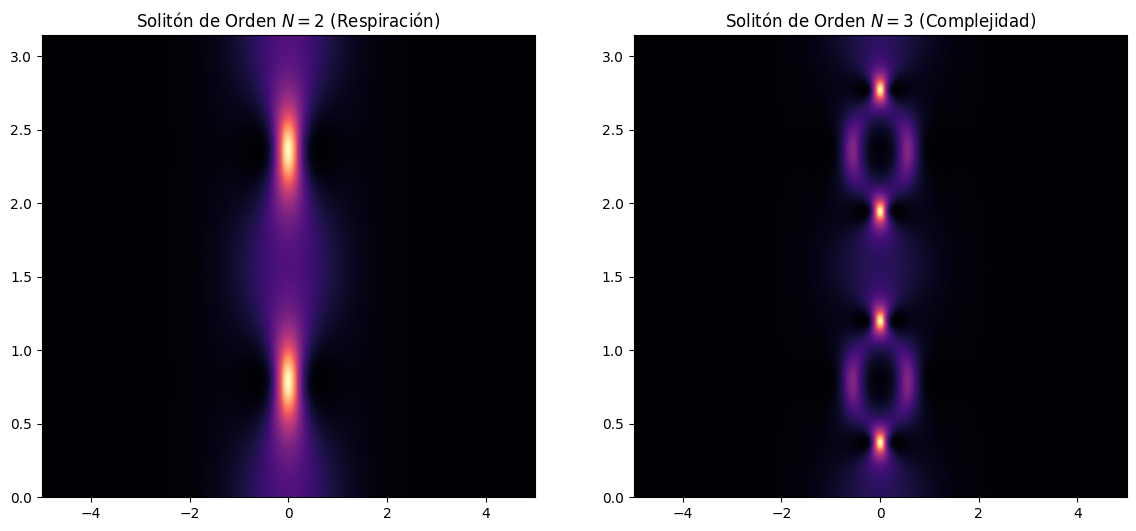

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

def simular_N_orden(N_order, xi_max=np.pi):

    # ==========================================
    # Mallado temporal
    # ==========================================
    N_t = 4096
    T_max = 20.0

    tau = np.linspace(-T_max, T_max, N_t)

    dtau = tau[1] - tau[0]

    omega = fftfreq(N_t, d=dtau) * 2 * np.pi

    # ==========================================
    # Mallado espacial
    # ==========================================
    N_xi = 2000

    dxi = xi_max / N_xi

    # ==========================================
    # Condición inicial
    # ==========================================
    U = N_order / np.cosh(tau)

    evo = np.zeros((N_xi, N_t))

    # ==========================================
    # Operador dispersivo (medio paso)
    # ==========================================
    D_half = np.exp(-1j * (omega**2 / 2) * dxi / 2)

    # ==========================================
    # SSFM simétrico
    # ==========================================
    for i in range(N_xi):

        evo[i, :] = np.abs(U)**2

        # Medio paso dispersivo
        U = ifft(fft(U) * D_half)

        # Paso no lineal
        U = U * np.exp(1j * np.abs(U)**2 * dxi)

        # Medio paso dispersivo
        U = ifft(fft(U) * D_half)

    return tau, np.linspace(0, xi_max, N_xi), evo

# Simulación
tau, xi, evo_n2 = simular_N_orden(2.0, np.pi)
tau, xi, evo_n3 = simular_N_orden(3.0, np.pi)

# Graficación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pcolormesh(tau, xi, evo_n2, cmap='magma', shading='auto')
ax1.set_title('Solitón de Orden $N=2$ (Respiración)')
ax1.set_xlim([-5, 5])

ax2.pcolormesh(tau, xi, evo_n3, cmap='magma', shading='auto')
ax2.set_title('Solitón de Orden $N=3$ (Complejidad)')
ax2.set_xlim([-5, 5])

plt.show()